# Week 3: Vector Space Semantics (Embeddings & MLPs)

Focused plan: tokenizer → IDs → embeddings → simple model → real‑world usage.


## Day 1: Tokenizer → IDs → Embedding Inputs
We reuse the Week 2 tokenizer outputs to build vocabulary, IDs, padding, and masks.


In [1]:
from utils import (
    get_imdb_corpus,
    save_json, 
    load_json, 
    train_bpe, 
    create_vocab_mapping, 
    convert_text_to_token_ids,
    save_torch_dataset,
    load_torch_dataset
)

In [2]:
# texts, labels = get_imdb_corpus()

In [2]:
max_seq = 128
pad_token = "[PAD]"
bpe_merges = load_json("datasets/bpe_merges.json")
bpe_vocab = load_json("datasets/bpe_vocab.json")

In [4]:
# bpe_merges = train_bpe(texts, vocab_size=500, min_freq=5, byte_level=True) 
# save_json("datasets/bpe_merges.json", bpe_merges)

In [5]:
# bpe_vocab = create_vocab_mapping(bpe_merges, pad_token = "[PAD]")
# save_json("datasets/bpe_vocab.json", bpe_vocab)
# vocab_config = {
#     "pad_token": pad_token,
#     "pad_id": bpe_vocab[pad_token],
#     "byte_vocab_size": 256,
#     "max_seq": max_seq,
#     "num_merges": len(bpe_merges),
#     "vocab_size": len(bpe_vocab)
# }
# save_json("models/vocab_config.json", vocab_config)

In [6]:
# tokenized_features = []
# attention_masks = []
# pad_token = "[PAD]"
# max_seq = 128 
# for i, text in enumerate(texts):
#     if i % 1000 == 0 :
#         print(i)
#     tokenized_text, attention_mask = convert_text_to_token_ids(
#         text,
#         bpe_merges,
#         bpe_vocab,
#         max_seq,
#         pad_token
#     )
#     tokenized_features.append(tokenized_text)
#     attention_masks.append(attention_mask)
# save_torch_dataset(tokenized_features, labels, attention_masks, "datasets/imdb_bpe_dataset.pt")

In [7]:
# input_ids, labels, attention_masks = load_torch_dataset("datasets/imdb_bpe_dataset.pt")

In [8]:
# len(input_ids), len(labels), len(attention_masks)

## Day 2: Train a Simple Embedding Model (DAN)
A Deep Averaging Network (DAN) model to learn embedding model 
Embedding → mean pool → dropout -> hidden -> relu -> dropoout -> linear → sentiment binary classifier.


In [3]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, random_split, DataLoader
from utils import clean_memory, get_device, evaluate_model, train_test_model

In [4]:
class DAN(nn.Module):
    def __init__(self, vocab_size, embedding_size, padding_idx, hidden_dim, n_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size,padding_idx=padding_idx)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(embedding_size, hidden_dim)
        self.linear = nn.Linear(hidden_dim, n_classes)

    def forward(self, input_ids, mask):
        embedding = self.embedding(input_ids)
        mask = mask.unsqueeze(-1).float()
        masked_embedding = embedding * mask
        mean_pool = masked_embedding.sum(dim=1)/mask.sum(dim=1).clamp(min=1)
        mean_pool = self.dropout(mean_pool)
        hidden = self.hidden(mean_pool) 
        hidden = torch.relu(hidden)
        hidden = self.dropout(hidden)
        return self.linear(hidden)

In [5]:
vocab_config = load_json("models/vocab_config.json")
pad_id = vocab_config["pad_id"]
vocab_size = vocab_config["vocab_size"]
max_seq = vocab_config["max_seq"]
embedding_size = 384
hidden_dim = embedding_size * 2 
dropout = 0.2
device = get_device()
model = DAN(vocab_size, embedding_size, pad_id, hidden_dim, 1, dropout).to(device)
criterion = nn.BCEWithLogitsLoss()
patience = 5
num_epochs = 20

In [12]:
# dataset = TensorDataset(input_ids, attention_masks, labels.float())
# n = len(dataset)
# n_train = int(0.8*n)
# n_val = int(0.1*n)
# n_test = n - n_train - n_val
# g = torch.Generator().manual_seed(204)
# train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)
# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_ds, batch_size=16)
# test_loader = DataLoader(test_ds, batch_size=16)

In [13]:
# clean_memory()

In [14]:
# best_model = train_test_model(
#     device = device,
#     model = model,
#     criterion=criterion,
#     train_loader = train_loader,
#     val_loader = val_loader,
#     patience = patience,
#     num_epochs=num_epochs,
#     lr=1e-3,
#     l2 = 1e-5,
#     is_binary=True
# )

In [15]:
# evaluate_model(model=best_model, data_loader=test_loader, criterion=criterion, device=device, is_binary=True)

In [16]:
# torch.save(best_model.state_dict(), "models/dan_imdb.pt")
# torch.save(best_model.embedding.state_dict(), "models/imdb_embedding_layer.pt")

## Day 3: Industry Embeddings comparison (Brief Overview)
- **GloVe:** Unsupervised word embeddings learned from word co‑occurrence statistics. It captures general semantic relationships but has no positional or contextual information, so the same word always maps to the same vector regardless of sentence.
- **SBert:** An encoder‑only Transformer that uses bidirectional attention to build sentence‑level embeddings (mean pooling). It captures context and semantics at the sentence level.
- **Trained Embedding:** Learns embeddings from the IMDB task. It does not model word order and uses mean pooling over token embeddings, but it still captures useful task‑specific semantics.

### Comparison:
The trained embeddings performed strongly on movie‑related similarity, which makes sense given they were trained on IMDB. GloVe performed worse because it is context‑free, and many different sentences can end up with similar averaged vectors. SBERT was strongest overall but the DAN model held its own in domain‑specific cases.

### To load GloVe model:
1. cd models
2. curl -L -O https://nlp.stanford.edu/data/glove.6B.zip
3. unzip glove.6B.zip


In [6]:
from sentence_transformers import SentenceTransformer
from utils import (
    bpe_batch_encode, 
    load_glove_txt, 
    get_glove_sent_embed, 
    get_sbert_embed, 
    get_dan_sent_embed, 
    plot_heatmap, 
    cos_sim_matrix
)

In [7]:
dan_model = DAN(vocab_size, embedding_size, pad_id, hidden_dim, 1,dropout)
state = torch.load("models/dan_imdb.pt", map_location="cpu")
dan_model.load_state_dict(state)
dan_embedding = dan_model.embedding
dan_embedding.weight.requires_grad_(False)

Parameter containing:
tensor([[-9.7074e-33, -1.0367e-32, -9.8843e-33,  ...,  1.0165e-32,
         -9.6537e-33, -9.4857e-33],
        [-1.0081e-32,  9.7738e-33,  1.0043e-32,  ...,  1.0324e-32,
         -9.4619e-33, -9.4838e-33],
        [-9.6240e-33,  9.8906e-33,  1.0212e-32,  ..., -1.0193e-32,
          1.1349e-32, -1.0232e-32],
        ...,
        [ 1.0774e-01,  9.6766e-02, -9.4411e-02,  ...,  5.0047e-01,
         -3.6577e-01, -2.2026e-01],
        [-1.2626e-02,  2.9294e-01, -7.2014e-02,  ..., -1.3461e-01,
         -2.1163e-01, -1.7965e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

In [8]:
sentences = [
    "I loved the movie, it was fantastic.",
    "The film was terrible and boring.",
    "An airplane took off from the runway.",
    "I really enjoyed the plot and the acting.",
    "The dog chased the ball in the park."
]

In [9]:
# DAN sentence embeddings
input_ids, attention_mask = bpe_batch_encode(sentences, bpe_merges, bpe_vocab, max_seq, pad_token)
dan_sent_emb = get_dan_sent_embed(dan_embedding, input_ids, attention_mask)
# GloVe sentence embeddings
glove = load_glove_txt(path="models/glove.6B.300d.txt", dim=300)
glove_sent_emb = torch.stack([get_glove_sent_embed(s, glove, 300) for s in sentences])
# SBERT sentence embeddings
sbert = SentenceTransformer("all-MiniLM-L6-v2")
sbert_sent_emb = get_sbert_embed(sbert, sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


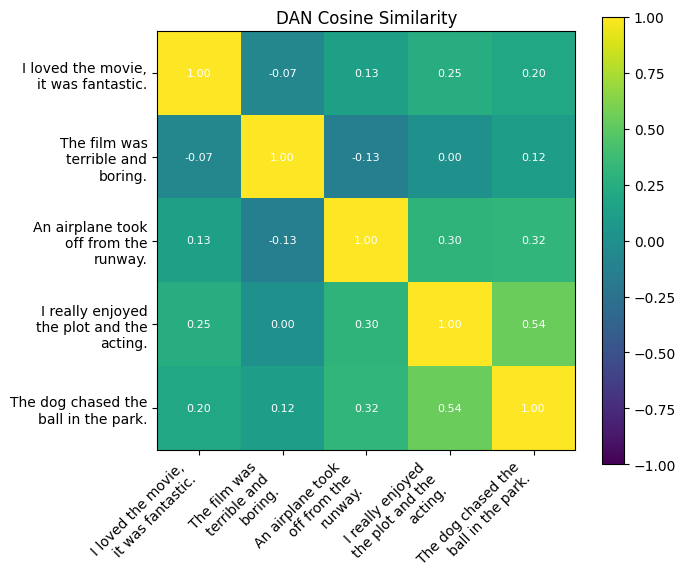

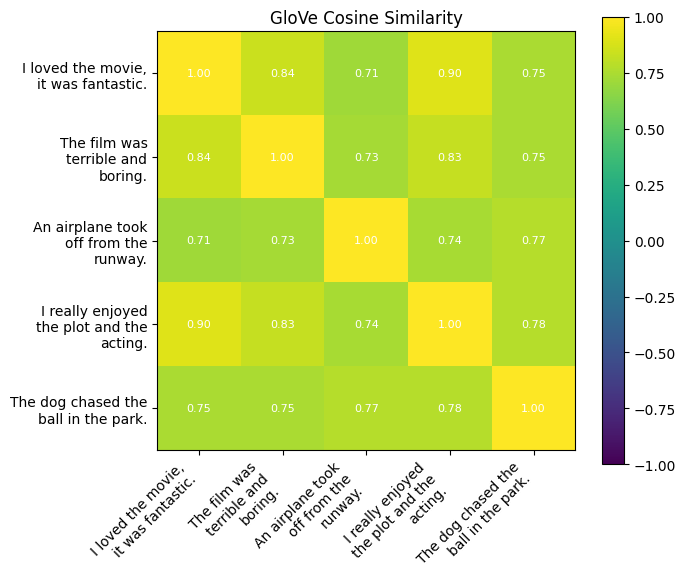

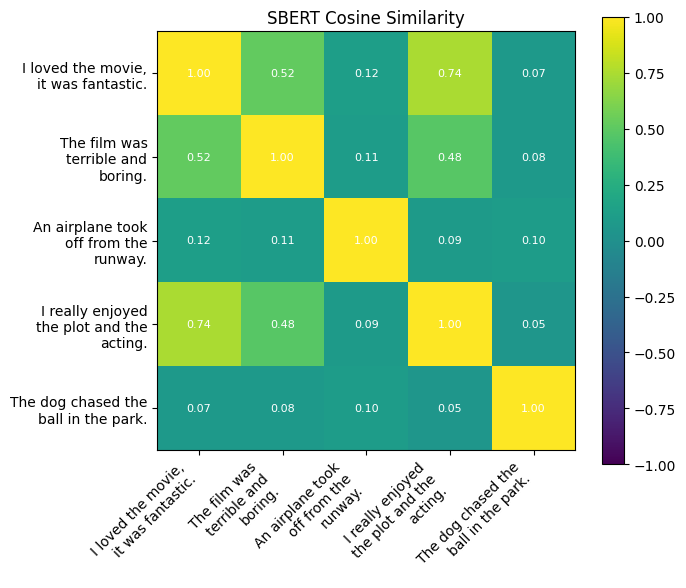

In [10]:
# use the actual sentences for both axes
plot_heatmap(cos_sim_matrix(dan_sent_emb), "DAN Cosine Similarity", sentences)
plot_heatmap(cos_sim_matrix(glove_sent_emb), "GloVe Cosine Similarity", sentences)
plot_heatmap(cos_sim_matrix(sbert_sent_emb), "SBERT Cosine Similarity", sentences) 

## Day 4: Real‑World Embedding Uses
Similarity search, nearest neighbors, retrieval context

### RAG‑Style Semantic Search (Retrieval Demo)
We build embeddings for a small out‑of‑domain corpus and retrieve the most relevant snippets for a query.
You can swap the embedder (SBERT, DAN, or GloVe).We use similarity search result for the most relevant context. 


In [11]:
from utils import semantic_search,print_embedding_result

In [12]:
imdb_like_docs = [
    "The movie was a thrilling ride from start to finish.",
    "I loved the performances, but the plot felt a little predictable.",
    "The film was painfully slow and far too long.",
    "An emotional story with beautiful cinematography and a powerful ending.",
    "The acting was wooden, and the dialogue sounded unnatural.",
    "I was completely drawn into the world of the movie.",
    "The pacing was uneven, but the soundtrack was excellent.",
    "This was one of the funniest comedies I have seen in years.",
    "The ending was disappointing after such a strong opening.",
    "A visually stunning film with very little substance underneath.",
    "The lead actor carried the entire movie with a fantastic performance.",
    "I found the story confusing and hard to follow.",
    "The chemistry between the characters made the romance believable.",
    "It was a dull and forgettable sequel that added nothing new.",
    "The suspense kept me guessing until the final scene.",
    "I expected much more from such a talented cast.",
    "The script was sharp, clever, and full of memorable lines.",
    "Some scenes were powerful, but overall the movie felt messy.",
    "The direction was bold and creative, even if the story was strange.",
    "I would happily watch this film again.",
    "The jokes did not land, and the humor felt forced.",
    "A moving and heartfelt drama that stayed with me afterward.",
    "The special effects were impressive, but the characters were flat.",
    "This film was overrated and not worth the hype.",
    "A charming, well-acted movie that delivered exactly what I hoped for."
]


non_imdb_like_docs = [
    "Reset your router by holding the reset button for 10 seconds until the lights blink.",
    "Two-factor authentication adds a second step to verify your identity.",
    "A strong password uses a mix of letters, numbers, and symbols.",
    "Clear your browser cache to fix loading issues on some websites.",
    "Update your device regularly to install important security patches.",
    "A layover is the waiting time between connecting flights.",
    "Arrive at the airport two hours early for most domestic flights.",
    "Travel insurance can cover trip delays, cancellations, and medical emergencies.",
    "Jet lag can be reduced by gradually adjusting your sleep schedule before travel.",
    "Pack liquids in small containers when traveling with carry-on luggage.",
    "Dehydration symptoms include dry mouth, dizziness, and fatigue.",
    "A balanced meal usually includes protein, fiber, and healthy fats.",
    "Walking every day can support heart health and improve mood.",
    "Stretching regularly may improve flexibility and reduce injury risk.",
    "A fever is often a sign that the body is fighting an infection.",
    "A budget tracks income, expenses, and savings goals over time.",
    "An emergency fund helps cover unexpected costs like repairs or medical bills.",
    "Index funds spread investment risk across many companies.",
    "Compound interest helps savings grow faster over longer periods.",
    "Credit scores are influenced by payment history and credit utilization.",
    "A refund policy explains when customers can return products for money back.",
    "Shipping delays are more common during holidays and peak seasons.",
    "Data backups help protect against accidental loss and file corruption.",
    "Encryption protects sensitive information both in storage and in transit.",
    "APIs allow different software systems to communicate with each other."
]

docs = imdb_like_docs + non_imdb_like_docs

### Check for performance for both imdb and non imdb_queries

In [13]:
imdb_query = "I want a movie with strong acting and an emotional story."
non_imdb_query = "How can I make my online account more secure?"
all_queries = [imdb_query, non_imdb_query]
# ---- DAN embeddings ----
doc_ids, doc_mask = bpe_batch_encode(docs, bpe_merges, bpe_vocab, max_seq, pad_token)
dan_doc_embs = get_dan_sent_embed(dan_embedding, doc_ids, doc_mask)
dan_query_fn = lambda q: get_dan_sent_embed(dan_embedding, *bpe_batch_encode([q], bpe_merges, bpe_vocab, max_seq, pad_token))[0]

# ---- GloVe embeddings ----
glove_doc_embs = torch.stack([get_glove_sent_embed(s, glove, 300) for s in docs])
glove_query_fn = lambda q: get_glove_sent_embed(q, glove, 300)

# ---- SBERT embeddings ----
sbert_doc_embs = sbert.encode(docs, convert_to_tensor=True)
sbert_query_fn = lambda q: sbert.encode([q], convert_to_tensor=True)[0]

model_mappings = {
    "DAN":{
        "doc_embs": dan_doc_embs,
        "query_fn": dan_query_fn
    },
    "GloVe": {
        "doc_embs": glove_doc_embs,
        "query_fn": glove_query_fn,
    },
    "SBERT": {
        "doc_embs": sbert_doc_embs,
        "query_fn": sbert_query_fn
    }
    
}

for model_type, emb_dict in model_mappings.items():
    for query in all_queries:
        print(f"\nquery questions: {query}")
        print_embedding_result(query, docs, emb_dict["doc_embs"], emb_dict["query_fn"], 2, model_type)
        print("---"*36)


query questions: I want a movie with strong acting and an emotional story.

 DAN semantic search:
0.442511 | An emotional story with beautiful cinematography and a powerful ending.
0.389406 | A visually stunning film with very little substance underneath.
------------------------------------------------------------------------------------------------------------

query questions: How can I make my online account more secure?

 DAN semantic search:
0.492045 | A refund policy explains when customers can return products for money back.
0.401623 | Travel insurance can cover trip delays, cancellations, and medical emergencies.
------------------------------------------------------------------------------------------------------------

query questions: I want a movie with strong acting and an emotional story.

 GloVe semantic search:
0.908559 | A moving and heartfelt drama that stayed with me afterward.
0.882003 | An emotional story with beautiful cinematography and a powerful ending.
-----

## Summary

* SBERT did best because it is built for sentence-level semantic similarity across general domains.
* GloVe did well on the IMDB-like query but performed poorly on the non-IMDB query because averaging static word vectors loses context and often flattens sentence meaning.
* DAN did okay on IMDB-like text because it learned from movie-review sentiment data, so it has useful domain-specific signal there.
* DAN did poorly on non-IMDB text because it was not trained to generalize broadly across unrelated domains like security, travel, or finance.

This also shows that embedding model choice can strongly affect RAG quality, because retrieval depends on how well the embedding space captures the meaning of the query and documents. Better embeddings lead to more relevant retrieved context, while weaker or domain-mismatched embeddings can return irrelevant chunks and hurt the final LLM response.

Tokenization turns raw text into discrete units, ID mapping makes them model-ready, and embeddings translate those IDs into dense vectors.
Mean pooling and simple classifiers show how token-level representations become sentence-level features.
This setup does not model attention or positional relationships, which are added later in Transformer-based LLMs.
These steps mirror the front end of modern LLM pipelines: tokenize → ids → embeddings → downstream reasoning or generation.